In [1]:
## Multi-Classification model
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import Subset

from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

from torchmetrics import ConfusionMatrix,Accuracy
from mlxtend.plotting import plot_confusion_matrix

from sklearn.model_selection import train_test_split
import numpy as np

import matplotlib.pyplot as plt
from tqdm.autonotebook import tqdm
from timeit import default_timer as timer

C:\Users\Admin\AppData\Local\Temp\ipykernel_12120\3398577688.py:18: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:


train_transform= transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),   # there is 50% chance of fliping an image in the dataset. the p is probablity that is between 0 to 1
    transforms.RandomRotation(degrees=20),    # Rotates some of the images to 20 degree
    transforms.ToTensor()
])

test_transform = transforms.Compose([transforms.ToTensor()])

"""
The Three Core Operations of ToTensor():
When you pass an image through ToTensor(), it performs three distinct transformations under the hood:

1. Permutes the dimensions (H x W x C ---> C x H x W):
Input: Images are typically loaded as (Height, Width, Channels). For example, an RGB image is (H, W, 3).
Output: PyTorch Convolutional layers expect the channel dimension to come first, resulting in (Channels, Height, Width) or (3, H, W).

2. Scales the pixel values from [0, 255] to [0.0, 1.0]:
Input: Pixel values in common image formats range from integer 0 to 255.
Output: The values are divided by 255.0 and converted to floats, scaling them between 0.0 and 1.0.
Neural networks train much more stably and efficiently with small, normalized float values.

3. Converts the data type to a PyTorch FloatTensor:
Input: uint8 or PIL.Image formats.
Output: torch.float32.
"""


train_data = datasets.EuroSAT(root='data',
                        download=True,
                        transform= train_transform,
                        target_transform=None)


test_data = datasets.EuroSAT(root='data',
                             download=True,
                             transform = test_transform,
                             target_transform=None)

# Getting the random index for test and train using numpy
indices = np.arange(len(train_data))
train_idx,test_idx = train_test_split(indices,test_size=0.2,stratify=train_data.targets)

# Making Train and Test data using random index formed from train_test_split
train_data = Subset(train_data,train_idx)
test_data = Subset(test_data, test_idx)

# Setting the data loaders
BATCH_SIZE = 42
train_dataloader = DataLoader(dataset= train_data,shuffle=True,batch_size=BATCH_SIZE)
test_dataloader = DataLoader(dataset= test_data,shuffle=True,batch_size=BATCH_SIZE)

class_names = train_data.dataset.classes
print('Unique class names in the data:\n',class_names)


# Device Agnostic Code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device: ',device)

Unique class names in the data:
 ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
device:  cpu


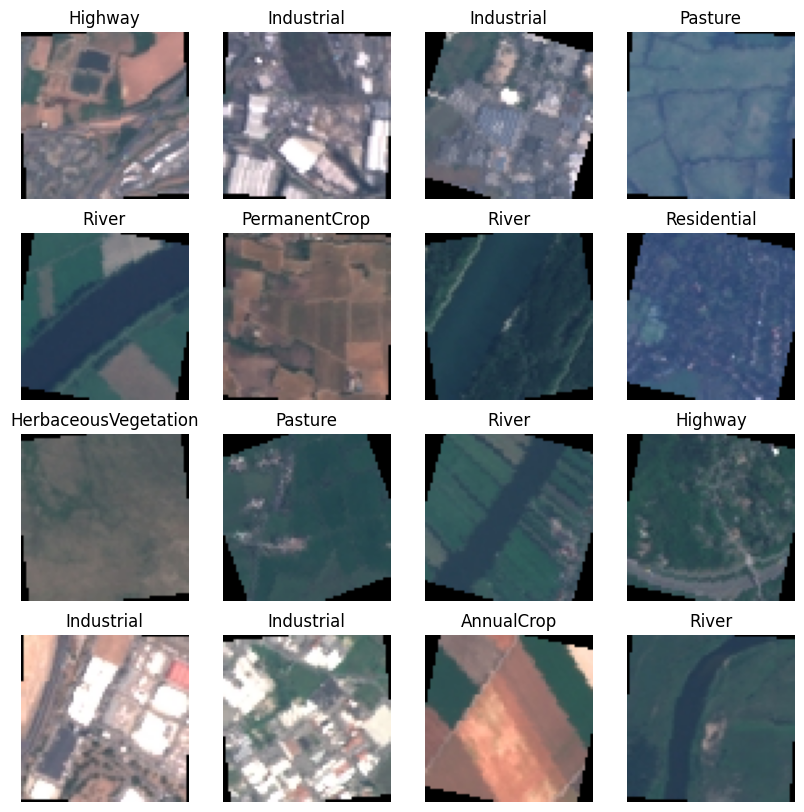

In [3]:
# visualizing a single image
torch.manual_seed(42)
fig = plt.figure(figsize=(10,10))
rows,columns = 4,4
for i in range(1,rows*columns + 1):
    random_idx = torch.randint(0,len(train_data),size=[1]).item()
    image,label = train_data[random_idx]
    image = image.permute(2,1,0)
    fig.add_subplot(rows,columns,i)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis(False)


In [4]:
# Creating the Model
class Eurosat(nn.Module):
    def __init__(self,in_size: int, hidden_units: int, out_size: int):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=in_size,out_channels=hidden_units,kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=(3,3),padding=1,stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.conv_block3 = nn.Sequential(
             nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features= hidden_units*8*8,out_features=out_size)
        )
    def forward(self,x: torch.Tensor) -> torch.Tensor:
        z = self.classifier(self.conv_block3(self.conv_block2(self.conv_block1(x))))
        return z

In [ ]:
torch.manual_seed(42)

# Model Instance
model_euro = Eurosat(in_size=3,hidden_units=20,out_size=len(class_names)).to(device)

# Assigning Loss and Optimizers
loss_fn_euro = nn.CrossEntropyLoss()
opti_fun_euro = torch.optim.SGD(model_euro.parameters(),0.01,weight_decay=1e-4)

# Creating necessary functions
def calculate_accuracy(y_true: torch.Tensor, y_pred: torch.Tensor):
    """Calculates the accuracy of the model for the given data"""
    x = torch.eq(y_true,y_pred).sum().item()
    acc = x/len(y_pred)*100
    return acc

def train_loop(model: nn.Module, data: torch.utils.data.DataLoader,
               loss_fn: nn.Module, optimizer: torch.optim.Optimizer, accuracy_fn,device: str, epoch: int):
    """Calculates the model training loop"""
    train_loss = 0
    train_acc = 0
    model.train()
    for batch,(X,y) in enumerate(data):
        X,y = X.to(device),y.to(device)
        y_pred = model(X)

        loss = loss_fn(y_pred,y)
        train_loss += loss
        train_acc += accuracy_fn(y,y_pred.argmax(dim=1))

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(data)
    train_acc /= len(data)

    if epoch % 20 == 0 or epoch ==1:
      print(f'Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}%')

    return train_loss,train_acc

def test_loop(model:nn.Module,data:torch.utils.data.DataLoader,
              loss_fn: nn.Module,accuracy_fn,device: str,epoch: int):
    """Calculates the model testing loop"""
    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X,y in data:
            X,y = X.to(device),y.to(device)
            y_pred = model(X)

            test_loss += loss_fn(y_pred,y)
            test_acc += accuracy_fn(y,y_pred.argmax(1))
        test_loss /= len(data)
        test_acc /= len(data)
        if epoch % 20 == 0 or epoch == 1:
          print(f'Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%')

    return test_loss,test_acc

def eval_model(model: nn.Module,data: torch.utils.data.DataLoader,
               loss_fn: nn.Module,accuracy_fn,device:str):
    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X,y in data:
            X,y = X.to(device),y.to(device)
            y_pred = model(X)

            test_loss += float(loss_fn(y_pred,y))
            test_acc += float(accuracy_fn(y,y_pred.argmax(1)))
        test_loss /= len(data)
        test_acc /= len(data)

    return     {'Model Name': model.__class__.__name__,
                'Model Loss': f'{test_loss:.4f}',
                'Model Accuracy': f'{test_acc:.2f}%'}

def train_time(start,end,device):
    """Calculates the time taken by the model to present the predicted output"""
    tot_time = end-start
    print(f'Time Taken by the model on {device}: {tot_time}')
    return tot_time

start_time = timer()
epochs = 200
train_loss_values = []
test_loss_values = []
epoch_values = []
for epoch in tqdm(range(1,epochs+1)):
    if epoch % 20 ==0 or epoch == 1 :
      tqdm.write(f'\n Epoch: {epoch} \n-------------')
    train_loss,train_acc = train_loop(model_euro,train_dataloader,loss_fn_euro,
                                      opti_fun_euro,calculate_accuracy,device,epoch)
    test_loss,test_acc =  test_loop(model_euro,test_dataloader,loss_fn_euro,calculate_accuracy,device,epoch)

    if epoch % 10 == 0:
      train_loss_values.append(train_loss)
      test_loss_values.append(test_loss)
      epoch_values.append(epoch)

end_time = timer()
train_timing = train_time(start_time,end_time,device)

In [ ]:
plt.figure(figsize=(5,5))
plt.plot(epoch_values,torch.tensor(train_loss_values).cpu().numpy(),label='Train Loss')
plt.plot(epoch_values,torch.tensor(test_loss_values).cpu().numpy(),label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Test Loss')
plt.legend(prop={'size':10});

In [ ]:
from pathlib import Path
model_save = Path('models')
model_save.mkdir(parents=True,exist_ok=True)

model_name = 'Multiclass_EurosatModel_colour_images.pth'
modelsavepath = model_save/model_name
print(f'saving model to the path {modelsavepath}')
torch.save(obj=model_euro.state_dict(),f=modelsavepath)

In [5]:
# Loading the model with the state_dict values of the model 'Eurosat' which was run in google collab
loaded_model = Eurosat(in_size=3,hidden_units=20,out_size=10)
loaded_model.load_state_dict(state_dict=torch.load('models/Multiclass_EurosatModel_colour_images.pth',torch.device('cpu')))
loaded_model

Eurosat(
  (conv_block1): Sequential(
    (0): Conv2d(3, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, i

In [6]:
y_preds = []
loaded_model.eval()
with torch.inference_mode():
    for X,y in tqdm(test_dataloader,desc='Making Predictions.....'):
        X,y = X.to(device),y.to(device)
        test_logit = loaded_model(X)
        test_pred = torch.softmax(test_logit.squeeze(),dim=0).argmax(dim=1)
        y_preds.append(test_pred.cpu())
           
y_preds = torch.cat(y_preds)
print(y_preds)
print(y_preds.shape)

Making Predictions.....:   0%|          | 0/129 [00:00<?, ?it/s]

tensor([6, 6, 5,  ..., 9, 4, 9])
torch.Size([5400])


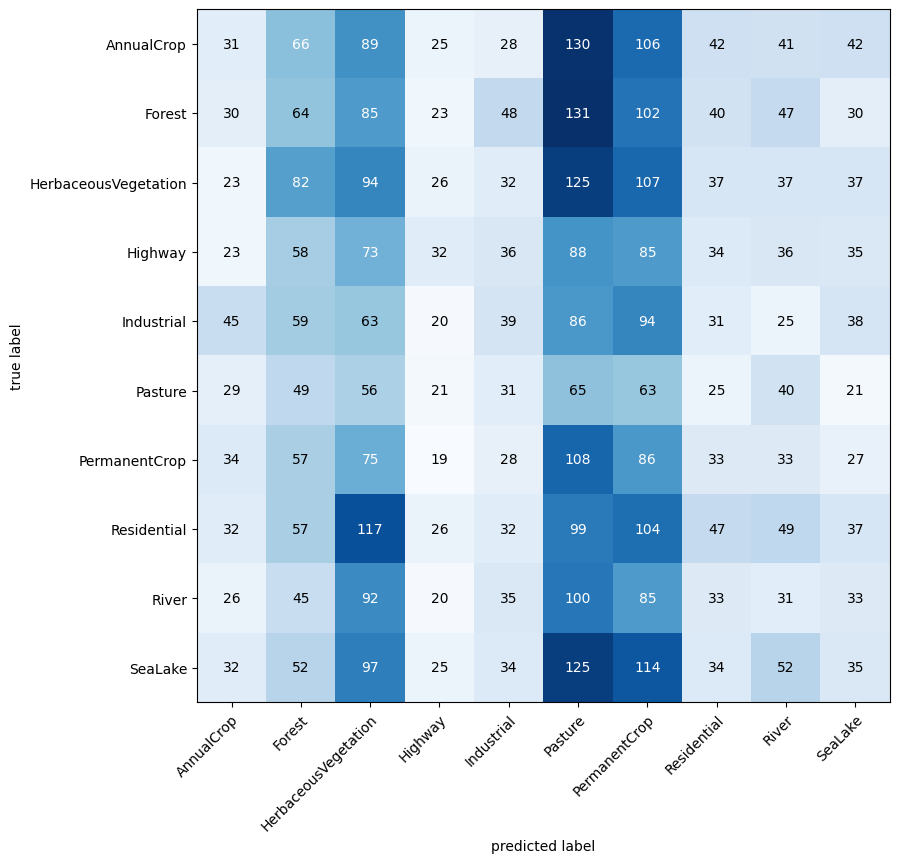

In [7]:
confmat = ConfusionMatrix(task='multiclass',num_classes=len(class_names)).to(device)
confmat_tensor = confmat(preds = y_preds, target=torch.tensor(np.array(test_data.dataset.targets)[test_idx])).to(device)

fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.numpy(),figsize=(9,9),class_names=class_names)


In [31]:
def predictions(data: list,model: nn.Module,device: str):
    model.eval()
    y_probs = []
    with torch.inference_mode():
        for i in data:
            i = i.unsqueeze(dim=0).to(device)
            y_logit = model(i)
            y_prob = torch.softmax(y_logit.squeeze(),dim=0)
            y_probs.append(y_prob)
    y_probs = torch.stack(y_probs)
    return y_probs

In [30]:
import random
torch.manual_seed(42)
test_sample = []
test_label = []
for sample, label in random.sample(list(test_data),k=16):
    test_sample.append(sample)
    test_label.append(label)   

In [32]:
test_label

[3, 8, 2, 3, 9, 9, 7, 7, 5, 0, 1, 3, 4, 1, 8, 7]

In [33]:
test_probs = predictions(test_sample,loaded_model,device)
test_pred = test_probs.argmax(dim=1)
test_pred

tensor([3, 8, 2, 3, 9, 9, 7, 7, 5, 0, 1, 3, 4, 1, 8, 7])

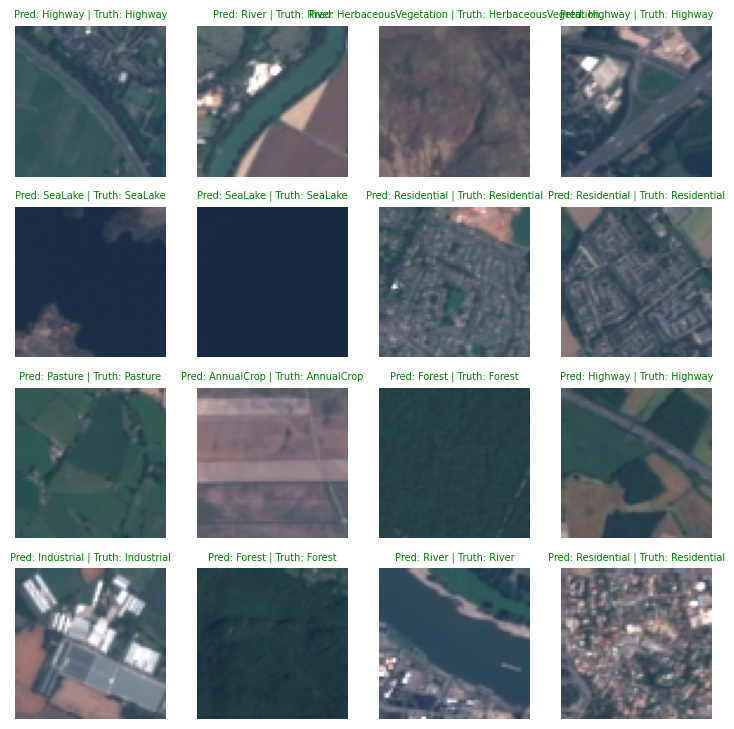

In [36]:
from textwrap import fill
import matplotlib.pyplot as plt
plt.figure(figsize=(9,9))
nrows = 4
ncols = 4
for i,sample in enumerate(test_sample):
    plt.subplot(nrows,ncols,i+1)
    sample = sample.to(device)
    sample = sample.permute(2,1,0)
    plt.imshow(sample)
    test_labels = class_names[test_pred[i]]
    truth_label = class_names[test_label[i]]
    title = (f'Pred: {test_labels} | Truth: {truth_label}')
    if test_labels == truth_label:
        plt.title(title,fontsize=7,color='g')
    else:
        plt.title(title,fontsize=7,color='r')
    plt.axis(False)
